# Mini-Project 1: UBOS District Population Forecaster

**Scenario.** A district planning unit needs 5-year population forecasts (2025–2029) to plan primary-school classrooms.

**My approach.**
1. Model each district as a validated `DistrictPopulation` object (in `src/population.py`).
2. Describe the data (statistics vs NumPy), then measure growth (year-on-year and CAGR).
3. Build three forecasters on a shared abstract `Forecaster` base class (`src/common/forecasting.py`), which Mini-Project 5 reuses.
4. **Validate before forecasting**: train on 2015–2021, test on 2022–2024, pick the model with the lowest RMSE for each district.
5. Refit the chosen model on all 10 years, forecast 2025–2029 with bootstrap prediction intervals, and convert the growth into classrooms.

**Assumptions.**
* Population figures are in **thousands** and are *illustrative* (as stated in the brief). I added **Mbarara** and **Mukono** as two extra districts. Their figures are also illustrative: I chose them to be plausible in size and growth, but they are *not* UBOS data.
* Years are evenly spaced, so the models use the time index t = 0, 1, 2, … instead of the raw year.
* I select models by **RMSE** because large errors are the costly ones for planning (an underestimate leaves children without classrooms). MAE and MAPE are reported too.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.common.forecasting import LinearTrendForecaster, holdout_evaluate
from src.population import (CAGRForecaster, ClassroomPlanner, DistrictPopulation,
                            FibonacciRatioForecaster, bootstrap_interval, compare_models,
                            fibonacci_ratios)

SEED = 2026                      # used for every random step (bootstrap)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## Task 1: The `DistrictPopulation` class

The class stores `years` and `populations` as NumPy arrays and validates them when it is created: equal lengths, non-empty, no negative values, and consecutive years. It implements `__repr__` (a readable summary) and `__len__` (the number of years).

In [2]:
YEARS = np.arange(2015, 2025)
RAW = {
    "Kampala": [1200, 1250, 1300, 1350, 1420, 1500, 1580, 1650, 1720, 1800],
    "Wakiso":  [ 950, 1000, 1070, 1150, 1220, 1300, 1390, 1480, 1570, 1670],
    "Gulu":    [ 320,  330,  345,  360,  375,  390,  410,  430,  455,  480],
    # two extra districts (illustrative, chosen by me)
    "Mbarara": [ 470,  480,  492,  505,  518,  530,  545,  560,  575,  590],
    "Mukono":  [ 600,  625,  650,  680,  705,  735,  760,  790,  820,  850],
}
districts = [DistrictPopulation(name, YEARS, pops) for name, pops in RAW.items()]
for d in districts:
    print(repr(d), "| len =", len(d))

DistrictPopulation(name='Kampala', years=2015-2024, n=10, latest=1,800k) | len = 10
DistrictPopulation(name='Wakiso', years=2015-2024, n=10, latest=1,670k) | len = 10
DistrictPopulation(name='Gulu', years=2015-2024, n=10, latest=480k) | len = 10
DistrictPopulation(name='Mbarara', years=2015-2024, n=10, latest=590k) | len = 10
DistrictPopulation(name='Mukono', years=2015-2024, n=10, latest=850k) | len = 10


In [3]:
# Validation in action: each bad input raises a clear error instead of producing silent nonsense.
bad_inputs = {
    "unequal lengths": (YEARS, RAW["Gulu"][:-1]),
    "negative value": (YEARS, [-5] + RAW["Gulu"][1:]),
    "empty": ([], []),
}
for label, (yrs, pops) in bad_inputs.items():
    try:
        DistrictPopulation("Test", yrs, pops)
    except ValueError as err:
        print(f"{label:16s} -> ValueError: {err}")

unequal lengths  -> ValueError: years (10) and populations (9) differ in length
negative value   -> ValueError: populations cannot be negative
empty            -> ValueError: at least one observation is required


## Task 2: Descriptive statistics (`statistics` vs NumPy)

In [4]:
rows = []
for d in districts:
    s, n0, n1 = d.stats_with_statistics(), d.stats_with_numpy(ddof=0), d.stats_with_numpy(ddof=1)
    rows.append({"district": d.name, "mean": s["mean"], "median": s["median"],
                 "variance (statistics)": s["variance"], "np.var ddof=0": n0["variance"],
                 "np.var ddof=1": n1["variance"], "stdev (statistics)": s["stdev"],
                 "np.std ddof=0": n0["stdev"]})
stats_table = pd.DataFrame(rows).set_index("district")
stats_table

,mean,median,variance (statistics),np.var ddof=0,np.var ddof=1,stdev (statistics),np.std ddof=0
district,,,,,,,
Kampala,"1,477.00","1,460.00","42,601.11","38,341.00","42,601.11",206.40,195.81
Wakiso,"1,280.00","1,260.00","60,066.67","54,060.00","60,066.67",245.09,232.51
Gulu,389.50,382.50,"2,885.83","2,597.25","2,885.83",53.72,50.96
Mbarara,526.50,524.00,"1,660.06","1,494.05","1,660.06",40.74,38.65
Mukono,721.50,720.00,"7,083.61","6,375.25","7,083.61",84.16,79.85


In [5]:
# Hand check for Gulu: sample variance = sum of squared deviations / (n - 1)
g = np.array(RAW["Gulu"], dtype=float)
ss = np.sum((g - g.mean()) ** 2)
print(f"sum of squares = {ss:,.1f}; /(n-1) = {ss/9:,.2f}; /n = {ss/10:,.2f}")
assert np.isclose(ss / 9, stats_table.loc["Gulu", "variance (statistics)"])
assert np.isclose(ss / 10, stats_table.loc["Gulu", "np.var ddof=0"])

sum of squares = 25,972.5; /(n-1) = 2,885.83; /n = 2,597.25


**Why `statistics.variance` and `np.var` disagree.** `statistics.variance` computes the **sample** variance and divides the sum of squared deviations by **n − 1**. `np.var` by default computes the **population** variance and divides by **n**. With n = 10, NumPy's value is exactly 9/10 of the `statistics` value, as the table shows.

**What `ddof` does.** `ddof` means "delta degrees of freedom": NumPy divides by `n − ddof`. `ddof=0` (the default) gives the population variance. `ddof=1` gives the unbiased sample variance and matches `statistics.variance` (`statistics.pvariance` is the `ddof=0` equivalent). We lose one degree of freedom because the deviations are measured from the *sample mean*, which was itself estimated from the same data. Our 10 years are a sample from a longer process, so `ddof=1` is the appropriate choice here.

Note that for a **trending** series like these, the variance mostly measures *how much the population grew over the decade*, not random fluctuation. Kampala's large variance does not mean Kampala is "volatile".

## Task 3: Growth rates and CAGR

YoY growth = (P_t − P_{t−1}) / P_{t−1}. CAGR = (P_2024 / P_2015)^(1/9) − 1. There are 9 growth steps between 10 annual values.

In [6]:
growth = pd.DataFrame({d.name: d.yoy_growth() * 100 for d in districts}, index=YEARS[1:])
growth.index.name = "year"
print("Year-on-year growth (%)")
display(growth.round(2))

cagr = pd.DataFrame({
    "CAGR (%)": [d.cagr() * 100 for d in districts],
    "mean YoY (%)": [d.yoy_growth().mean() * 100 for d in districts],
    "absolute growth 2015-24 (k)": [d.populations[-1] - d.populations[0] for d in districts],
}, index=[d.name for d in districts]).sort_values("CAGR (%)", ascending=False)
cagr

Year-on-year growth (%)


,Kampala,Wakiso,Gulu,Mbarara,Mukono
year,,,,,
2016,4.17,5.26,3.12,2.13,4.17
2017,4.00,7.00,4.55,2.50,4.00
2018,3.85,7.48,4.35,2.64,4.62
2019,5.19,6.09,4.17,2.57,3.68
2020,5.63,6.56,4.00,2.32,4.26
2021,5.33,6.92,5.13,2.83,3.40
2022,4.43,6.47,4.88,2.75,3.95
2023,4.24,6.08,5.81,2.68,3.80
2024,4.65,6.37,5.49,2.61,3.66


,CAGR (%),mean YoY (%),absolute growth 2015-24 (k)
Wakiso,6.47,6.47,720.00
Kampala,4.61,4.61,600.00
Gulu,4.61,4.61,160.00
Mukono,3.95,3.95,250.00
Mbarara,2.56,2.56,120.00


In [7]:
# Second-method check: CAGR compounded over 9 years must reproduce the 2024 value
for d in districts:
    assert np.isclose(d.populations[0] * (1 + d.cagr()) ** 9, d.populations[-1])
print("Fastest-growing district in relative terms:", cagr.index[0])
print("Kampala/Gulu growth multiples:", RAW["Kampala"][-1] / RAW["Kampala"][0], RAW["Gulu"][-1] / RAW["Gulu"][0])

Fastest-growing district in relative terms: Wakiso
Kampala/Gulu growth multiples: 1.5 1.5


**Interpretation.** **Wakiso grows fastest in relative terms (≈ 6.5 % per year)**. That fits Wakiso absorbing Kampala's overspill as people move to the peri-urban ring. Kampala and Gulu have **identical** CAGRs (both grew by exactly 1.5×). In absolute terms, though, Kampala added 600k people and Gulu 160k. The planning load depends on *absolute* growth while the *rate* tells you about momentum, so we need both measures. The mean YoY growth is slightly higher than CAGR for every district because an arithmetic mean of rates overstates compound growth.

## Task 4: Three forecasting models

All three inherit from the abstract `Forecaster` class. `fit()` and `predict(horizon)` live in the base class and handle the validation; each subclass only implements the maths (`_fit` / `_predict`). This is the *template method* pattern, so the validation code is written once.

| Model | Rule | Learns from data |
|---|---|---|
| `LinearTrendForecaster` | y = a + b·t via `np.polyfit(t, y, 1)` | slope and intercept |
| `CAGRForecaster` | y_{n+k} = y_n (1 + g)^k, with g = training-period CAGR | growth rate g |
| `FibonacciRatioForecaster` | y_{n+k} = y_n · r_1 · r_2 ⋯ r_k, where r_j = F(j+1)/F(j) | nothing |

For the Fibonacci model, the brief only says it "scales the last value by successive Fibonacci ratios". **My interpretation** starts the ratio sequence at F(3)/F(2) = 2, giving the ratios 2, 1.5, 1.67, 1.6, 1.625, … → φ ≈ 1.618.

In [8]:
print("First Fibonacci ratios:", np.round(fibonacci_ratios(8, start=2), 4))
print("Golden ratio:", round((1 + 5 ** 0.5) / 2, 4))
MODELS = [LinearTrendForecaster(), CAGRForecaster(), FibonacciRatioForecaster(start=2)]
MODELS

First Fibonacci ratios: [2.     1.5    1.6667 1.6    1.625  1.6154 1.619  1.6176]
Golden ratio: 1.618


[LinearTrendForecaster(unfitted),
 CAGRForecaster(unfitted),
 FibonacciRatioForecaster(unfitted)]

## Task 5: Validate before forecasting (train 2015–2021, test 2022–2024)

In [9]:
LAST_TRAIN = 2021
best_models = {}
for d in districts:
    table = compare_models(d, MODELS, LAST_TRAIN)
    best_models[d.name] = table.loc[0, "model"]
    print(f"\n{d.name}: best = {table.loc[0, 'model']}")
    display(table)


Kampala: best = CAGR / exponential


,model,MAE,RMSE,MAPE (%)
0,CAGR / exponential,9.62,10.39,0.55
1,Linear trend,37.62,38.97,2.17
2,Fibonacci ratio,"3,543.33","4,025.36",202.00



Wakiso: best = CAGR / exponential


,model,MAE,RMSE,MAPE (%)
0,CAGR / exponential,6.80,8.05,0.42
1,Linear trend,49.40,52.37,3.09
2,Fibonacci ratio,"3,060.00","3,479.87",189.87



Gulu: best = CAGR / exponential


,model,MAE,RMSE,MAPE (%)
0,CAGR / exponential,9.44,10.87,2.02
1,Linear trend,18.57,20.29,4.01
2,Fibonacci ratio,911.67,"1,035.64",196.04



Mbarara: best = CAGR / exponential


,model,MAE,RMSE,MAPE (%)
0,CAGR / exponential,2.31,2.42,0.40
1,Linear trend,6.61,6.91,1.14
2,Fibonacci ratio,"1,241.67","1,409.81",213.62



Mukono: best = CAGR / exponential


,model,MAE,RMSE,MAPE (%)
0,CAGR / exponential,2.73,3.38,0.33
1,Linear trend,5.89,6.39,0.71
2,Fibonacci ratio,"1,713.33","1,946.54",205.84


In [10]:
# Hand check of one cell: CAGR model for Gulu
train = np.array(RAW["Gulu"][:7], float); test = np.array(RAW["Gulu"][7:], float)
g_hat = (train[-1] / train[0]) ** (1 / 6) - 1
pred = train[-1] * (1 + g_hat) ** np.arange(1, 4)
print("growth", round(g_hat, 4), "pred", pred.round(1), "RMSE", round(np.sqrt(np.mean((test - pred) ** 2)), 2))

growth 0.0422 pred [427.3 445.3 464.1] RMSE 10.87


**Model selection.** The **CAGR (exponential) model wins in every district**, with test MAPE below about 2 %. The linear trend under-forecasts 2022–2024 because these series are slightly *convex*: the yearly increments themselves grow. That is what constant-percentage growth looks like. The Fibonacci model is off by roughly 200 % after only three years, which is enough to rule it out.

One caveat: a 3-year test window is short, so an RMSE gap of a few thousand people is a weak basis for choosing a model. Still, the CAGR model was best in all five districts, and the convex shape gives a structural reason to expect it, so the choice holds up.

## Task 6: Forecast 2025–2029 with the selected model

In [11]:
MODEL_BY_NAME = {m.name: m for m in MODELS}
HORIZON = 5
FUTURE = np.arange(2025, 2025 + HORIZON)

forecasts, intervals = {}, {}
for d in districts:
    model = MODEL_BY_NAME[best_models[d.name]]
    pi = bootstrap_interval(model, d.populations, HORIZON, n_boot=1000, seed=SEED)
    forecasts[d.name] = pi["point"]
    intervals[d.name] = pi

forecast_table = pd.DataFrame(forecasts, index=FUTURE).T
forecast_table.columns.name = "year"
forecast_table.round(0)

year,2025,2026,2027,2028,2029
Kampala,"1,883.00","1,970.00","2,060.00","2,155.00","2,255.00"
Wakiso,"1,778.00","1,893.00","2,015.00","2,146.00","2,285.00"
Gulu,502.00,525.00,549.00,575.00,601.00
Mbarara,605.00,621.00,636.00,653.00,669.00
Mukono,884.00,918.00,955.00,992.00,"1,031.00"


In [12]:
var_rows = []
for d in districts:
    f = forecasts[d.name]
    var_rows.append({
        "district": d.name,
        "var(actual 2015-24)": np.var(d.populations, ddof=1),
        "var(forecast 2025-29)": np.var(f, ddof=1),
        "var of yearly increments, actual": np.var(np.diff(d.populations), ddof=1),
        "var of yearly increments, forecast": np.var(np.diff(np.r_[d.populations[-1], f]), ddof=1),
    })
pd.DataFrame(var_rows).set_index("district")

,var(actual 2015-24),var(forecast 2025-29),"var of yearly increments, actual","var of yearly increments, forecast"
district,,,,
Kampala,"42,601.11","21,607.68",175.00,41.93
Wakiso,"60,066.67","40,131.36",225.00,148.14
Gulu,"2,885.83","1,536.55",25.69,2.98
Mbarara,"1,660.06",647.07,3.25,0.40
Mukono,"7,083.61","3,420.00",6.94,4.93


**What the variance comparison tells us.** The forecast series has a much *smaller* variance than the actual series in every district. That does **not** mean the future is more certain:

1. For a trending series, variance measures how far the values spread around their own mean, which is mostly the size of the trend inside the window. The forecast covers 5 years and the history covers 10, so the forecast values spread less even though growth continues (and even accelerates).
2. A model forecast is a **smooth curve with no noise**. Real populations vary year to year (migration shocks, census revisions), and the point forecast contains none of that. The yearly increments make this visible: the actual increments jump around (Kampala: +50, +50, +50, +70, +80, +80, +70, +70, +80), while the forecast increments rise smoothly and their variance comes only from the exponential curvature.

So the variance of a point forecast **understates** uncertainty. Uncertainty should be shown with prediction intervals instead (extension below).

## Task 7: Actual, fitted and forecast values (plus 95 % bootstrap intervals)

For each district I plot:
* the actual data,
* the selected model **fitted on 2015–2021** (solid) and its out-of-sample predictions for 2022–2024 (dashed), so the validation is visible,
* the forecast for 2025–2029 from the model **refitted on all 10 years**, with its 95 % bootstrap interval shaded.

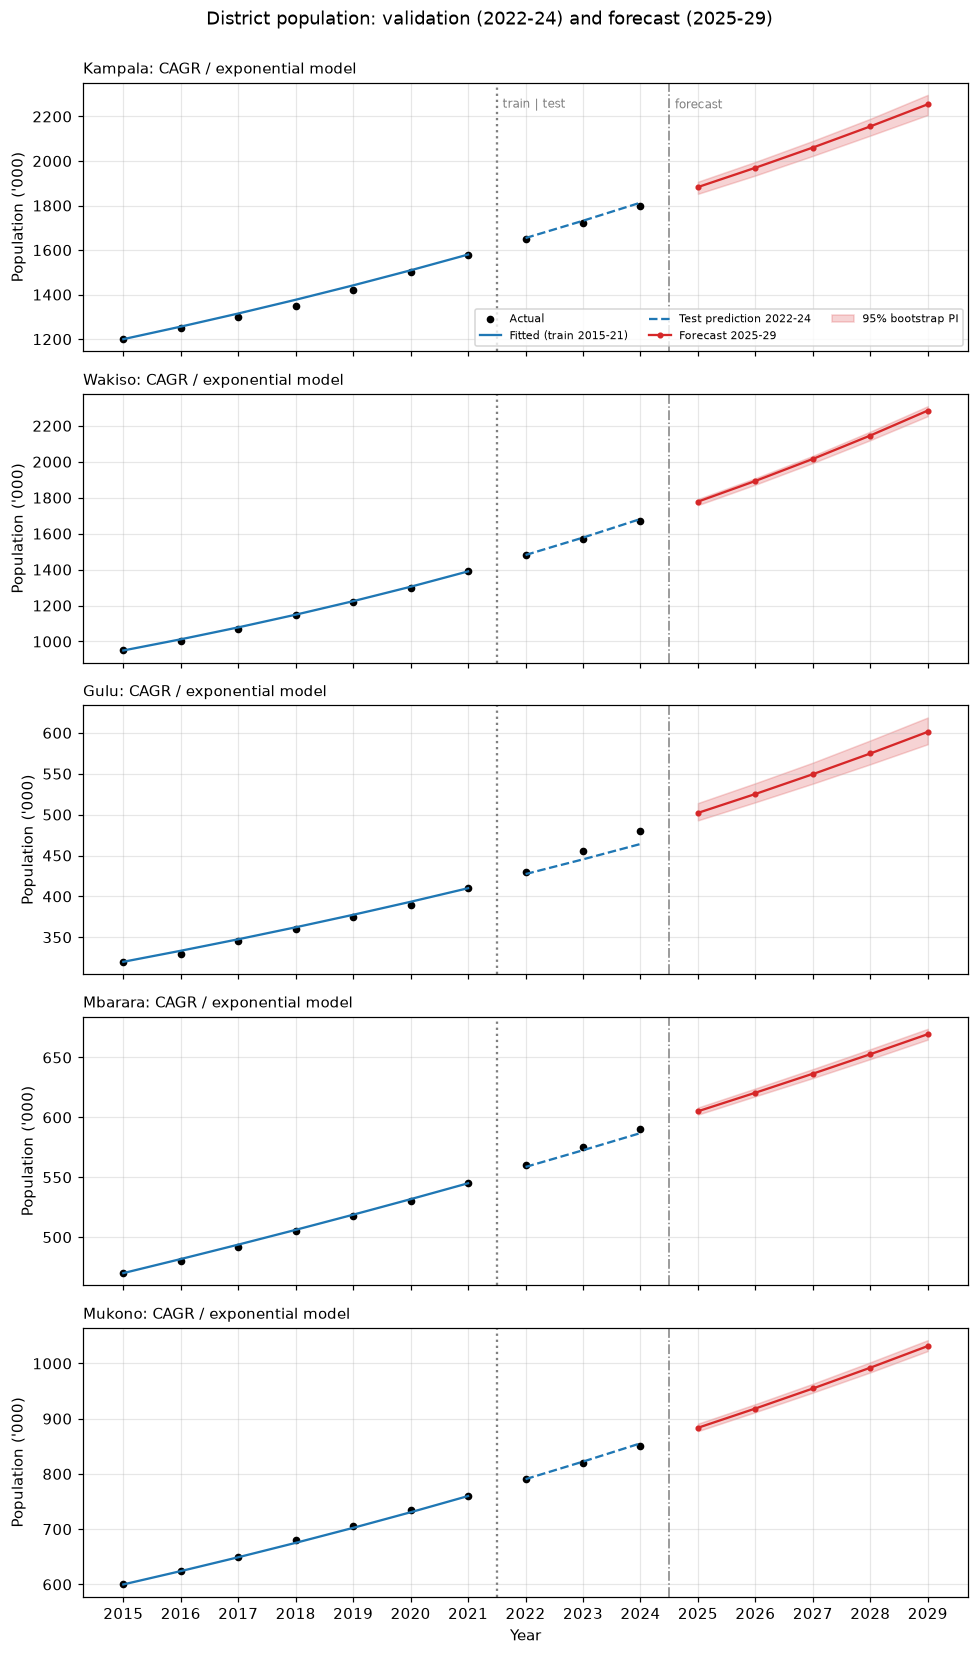

In [13]:
fig, axes = plt.subplots(len(districts), 1, figsize=(9, 3.0 * len(districts)), sharex=True)
for ax, d in zip(axes, districts):
    model = MODEL_BY_NAME[best_models[d.name]]
    n_train = int(np.sum(d.years <= LAST_TRAIN))
    val = holdout_evaluate(model, d.populations, n_train)
    ax.plot(d.years, d.populations, "o", color="black", ms=4, label="Actual")
    ax.plot(d.years[:n_train], val["model"].fitted_values(), color="tab:blue", label="Fitted (train 2015-21)")
    ax.plot(d.years[n_train:], val["predictions"], "--", color="tab:blue", label="Test prediction 2022-24")
    pi = intervals[d.name]
    ax.plot(FUTURE, pi["point"], color="tab:red", marker=".", label="Forecast 2025-29")
    ax.fill_between(FUTURE, pi["lower"], pi["upper"], color="tab:red", alpha=0.2, label="95% bootstrap PI")
    ax.axvline(LAST_TRAIN + 0.5, color="grey", ls=":", lw=1.5)
    ax.axvline(2024.5, color="grey", ls="-.", lw=1)
    ax.set_title(f"{d.name}: {best_models[d.name]} model", loc="left", fontsize=10)
    ax.set_ylabel("Population ('000)")
axes[0].text(LAST_TRAIN + 0.6, axes[0].get_ylim()[1] * 0.97, "train | test", va="top", fontsize=8, color="grey")
axes[0].text(2024.6, axes[0].get_ylim()[1] * 0.97, "forecast", va="top", fontsize=8, color="grey")
axes[0].legend(fontsize=7, ncol=3, loc="lower right")
axes[-1].set_xlabel("Year")
axes[-1].set_xticks(np.arange(2015, 2030))
fig.suptitle("District population: validation (2022-24) and forecast (2025-29)", y=1.0)
fig.tight_layout()
fig.savefig("figures/p1_population_forecasts.png", bbox_inches="tight")
plt.show()

## Task 8: Planning output (additional classrooms by 2029)

additional classrooms = ⌈ (P_2029 − P_2024) × 1000 × 18 % / 53 ⌉

I round **up** because 0.4 of a classroom still has to be built. I also show the range implied by the 95 % prediction interval, since a planner should budget for the upper end.

In [14]:
planner = ClassroomPlanner(school_age_share=0.18, pupils_per_classroom=53)
plan = []
for d in districts:
    now, pi = d.populations[-1], intervals[d.name]
    plan.append({
        "district": d.name,
        "pop 2024 (k)": now, "pop 2029 (k)": pi["point"][-1],
        "extra pupils": planner.extra_pupils(now, pi["point"][-1]),
        "classrooms (point)": planner.additional_classrooms(now, pi["point"][-1]),
        "classrooms (PI low)": planner.additional_classrooms(now, pi["lower"][-1]),
        "classrooms (PI high)": planner.additional_classrooms(now, pi["upper"][-1]),
    })
plan_table = pd.DataFrame(plan).set_index("district")
display(plan_table.round(0))
print("Total additional classrooms (point):", plan_table["classrooms (point)"].sum())
# hand check, Gulu
p29 = intervals["Gulu"]["point"][-1]
print(f"Gulu: ({p29:.1f} - 480) * 1000 * 0.18 / 53 = {(p29 - 480) * 1000 * 0.18 / 53:.1f} -> rounded up")

,pop 2024 (k),pop 2029 (k),extra pupils,classrooms (point),classrooms (PI low),classrooms (PI high)
district,,,,,,
Kampala,"1,800.00","2,255.00","81,857.00",1545,1382,1688
Wakiso,"1,670.00","2,285.00","110,641.00",2088,1983,2170
Gulu,480.00,601.00,"21,829.00",412,361,472
Mbarara,590.00,669.00,"14,300.00",270,255,285
Mukono,850.00,"1,031.00","32,665.00",617,586,653


Total additional classrooms (point): 4932
Gulu: (601.3 - 480) * 1000 * 0.18 / 53 = 411.9 -> rounded up


## Extension A: Bootstrap prediction intervals

Method (`bootstrap_interval` in `src/population.py`), with 1,000 resamples:
1. Fit the model and compute residuals (actual − fitted), centred to mean zero.
2. For each resample, add randomly resampled residuals to the fitted curve to create a plausible alternative history, **refit the model on it** (this captures parameter uncertainty), forecast, and add one more resampled residual per future year (this captures year-to-year noise).
3. The 2.5th and 97.5th percentiles of the 1,000 forecast paths form the 95 % interval.

The intervals widen with the horizon, as they should. With only 10 points and a model that fits very well, they are narrow (about ±2–3 %). They capture only "more of the same" uncertainty. They do **not** cover structural breaks such as a new census rebasing or a boundary change that creates a new district.

## Extension B: Is the Fibonacci-ratio model ever defensible?

In [15]:
phi = (1 + 5 ** 0.5) / 2
print(f"Implied long-run growth per step: {(phi - 1) * 100:.1f}%")
print(f"Gulu after 5 steps from 480k: {FibonacciRatioForecaster().fit(RAW['Gulu']).predict(5).round(0)}")
print(f"Uganda's actual national growth is about 3% per year -> 5-year factor {1.03 ** 5:.3f} vs Fibonacci {np.prod(fibonacci_ratios(5, 2)):.1f}")

Implied long-run growth per step: 61.8%
Gulu after 5 steps from 480k: [ 960. 1440. 2400. 3840. 6240.]
Uganda's actual national growth is about 3% per year -> 5-year factor 1.159 vs Fibonacci 13.0


The ratios F(k+1)/F(k) converge to φ ≈ 1.618, so the model assumes the population grows **about 62 % per year** (more in the first step, since my start ratio is 2). It ignores the data except for the last value. No human population grows like that. Uganda's national growth is about 3 % a year, and even the fastest-growing district here manages about 6.5 %.

The Fibonacci recurrence N_{t+1} = N_t + N_{t−1} describes Fibonacci's idealised rabbits: every pair breeds every period, nobody dies, and there is no resource limit. The model is therefore defensible only if **(a)** the generation time equals the forecast step, **(b)** every individual reproduces at that fixed rate, **(c)** there is no mortality or out-migration, and **(d)** there is no limit from land, food or services. For a district population at yearly steps, none of these hold. The only way to rescue it is to treat it as a generic multiplicative model with *estimated* ratios, and then it simply becomes the CAGR model. **Conclusion:** it is not defensible for population planning. Its 200 % test MAPE confirms this.

## Findings & Limitations

**Findings.** All five districts grow at a steady, slightly accelerating percentage rate. Because of that, the constant-growth (CAGR) model beat the linear trend on held-out 2022–2024 data in every district, with test errors under 2 %. Wakiso is the fastest-growing district in relative terms (≈ 6.5 %/yr). Kampala, despite the same relative growth as Gulu (≈ 4.6 %/yr), adds the most people. For planning, absolute growth matters most. By 2029 the five districts need roughly **4,900 additional primary classrooms** (about 2,100 in Wakiso and 1,500 in Kampala), and the upper bound of the 95 % interval adds a few hundred more. That suggests the planning unit should budget for the upper bound and revise the plan every year.

**Limitations.** (1) The data are illustrative, and the two added districts are my own invention, so the numbers show the method rather than real needs. (2) Ten points and a three-year test window cannot reliably separate models that differ only in curvature. Exponential growth also compounds any error, so its 5-year forecasts are riskier than the narrow intervals suggest. (3) The bootstrap assumes past residual patterns continue. It ignores structural shocks such as boundary changes (new districts carved out), refugee inflows into northern districts like Gulu, or census rebasing. (4) The 18 % school-age share and 53 pupils per classroom are held constant. In practice, falling fertility would shrink the school-age share, and the classroom count ignores existing spare capacity, enrolment rates and private schools. These figures are therefore an upper-end estimate of *demand*, not a construction schedule.